In [1]:
import uproot
import pandas as pd
import numpy as np
import awkward as ak
import os
import json
import ROOT

In [17]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.lines as lines
from matplotlib.collections import PatchCollection
plt.rcParams.update({'font.size': 15})
import seaborn as sns

In [3]:
os.environ['ttH_yy_DIR'] = '/eos/user/e/elmazzeo/ttH@FCC-hh/results/2025-03-14/'

In [4]:
basedir = os.path.join(os.environ.get('ttH_yy_DIR'), 'final')
outdir = os.path.join(os.environ.get('ttH_yy_DIR'), 'plots')

process = {
    'ttHyy' : { 'sample_list' : ['mgp8_pp_tth01j_5f_84TeV_haaexcl'], 
               'label' : r'$ttH \rightarrow \gamma\gamma$', 'kfactor' : 1.},
}
remove_below_permille = True

In [5]:
selection = {
    'truth' : {
        'TTH_CEN_PTH_0_60' : '$|y_H|<4$, $p_T(H)<60$ GeV',
        'TTH_CEN_PTH_60_120' : '$|y_H|<4$, $60\leq p_T(H)<120$ GeV',
        'TTH_CEN_PTH_120_200' : '$|y_H|<4$, $120\leq p_T(H)<200$ GeV',
        'TTH_CEN_PTH_200_300' : '$|y_H|<4$, $200\leq p_T(H)<300$ GeV',
        'TTH_CEN_PTH_300_450' : '$|y_H|<4$, $300\leq p_T(H)<450$ GeV',
        'TTH_CEN_PTH_450_inf' : '$|y_H|>4$, $p_T(H)\geq 450$ GeV',
        'TTH_FWD' : '$|y_H|>4$',
    },
    'reco' : {
            "pT_yy_bin1" : "0$\leq p_{T}(\gamma\gamma)$< 60 GeV",
            "pT_yy_bin2" : "60$\leq p_{T}(\gamma\gamma)$< 120 GeV",
            "pT_yy_bin3" : "120$\leq p_{T}(\gamma\gamma)$< 200 GeV",
            "pT_yy_bin4" : "200$\leq p_{T}(\gamma\gamma)$< 300 GeV",
            "pT_yy_bin5" : "300$\leq p_{T}(\gamma\gamma)$< 450 GeV",
            "pT_yy_bin6" : "$p_{T}(\gamma\gamma)\geq$ 450 GeV",

    },
}

variables = ['weight']

process_infos = "/eos/experiment/fcc/hh/utils/FCCDicts/FCChh_procDict_fcc_v07_II.json"

lumi = 3e7 # 3 * 10^7 pb-1 = 3 ab-1

In [6]:
df = {}
sow = -1.

In [7]:
with open(process_infos, 'r') as f :
    process_dict = json.load(f)

In [8]:
process_name = list(process.keys())[0]
process_path = process[process_name]['sample_list'][0]
process_label = process[process_name]['label']
process_kfactor = process[process_name]['kfactor']

In [9]:
process_label

'$ttH \\rightarrow \\gamma\\gamma$'

In [10]:
for sel_truth in selection['truth'].keys() :
    df[sel_truth] = {}
    print(sel_truth)
    for sel_reco in selection['reco'].keys() :
        print("\t\t"+sel_reco)
        inputfile = os.path.join(basedir, process_path+"_"+sel_truth+"_"+sel_reco+".root")
        # get sum of weights
        f = ROOT.TFile.Open(inputfile)
        sow = f.Get("SumOfWeights").GetVal()
        f.Close()
        # get sample
        with uproot.open(inputfile) as f :
            if 'events;1' in list(f.keys()) :
                df[sel_truth][sel_reco] = ak.to_dataframe(f['events'].arrays(expressions=variables, library='ak'))
            else :
                df[sel_truth][sel_reco] = pd.DataFrame({'weight' : []})
        df[sel_truth][sel_reco]["weight"] = df[sel_truth][sel_reco]["weight"]/sow*process_dict[process_path]['crossSection']*process_dict[process_path]['kfactor']*process_dict[process_path]['matchingEfficiency']
        df[sel_truth][sel_reco]["weight"] = df[sel_truth][sel_reco]["weight"]*process_kfactor

TTH_CEN_PTH_0_60
		pT_yy_bin1
		pT_yy_bin2
		pT_yy_bin3
		pT_yy_bin4
		pT_yy_bin5
		pT_yy_bin6
TTH_CEN_PTH_60_120
		pT_yy_bin1
		pT_yy_bin2
		pT_yy_bin3
		pT_yy_bin4
		pT_yy_bin5
		pT_yy_bin6
TTH_CEN_PTH_120_200
		pT_yy_bin1
		pT_yy_bin2
		pT_yy_bin3
		pT_yy_bin4
		pT_yy_bin5
		pT_yy_bin6
TTH_CEN_PTH_200_300
		pT_yy_bin1
		pT_yy_bin2
		pT_yy_bin3
		pT_yy_bin4
		pT_yy_bin5
		pT_yy_bin6
TTH_CEN_PTH_300_450
		pT_yy_bin1
		pT_yy_bin2
		pT_yy_bin3
		pT_yy_bin4
		pT_yy_bin5
		pT_yy_bin6
TTH_CEN_PTH_450_inf
		pT_yy_bin1
		pT_yy_bin2
		pT_yy_bin3
		pT_yy_bin4
		pT_yy_bin5
		pT_yy_bin6
TTH_FWD
		pT_yy_bin1
		pT_yy_bin2
		pT_yy_bin3
		pT_yy_bin4
		pT_yy_bin5
		pT_yy_bin6


In [11]:
yields = np.ones(shape=(len(list(selection['reco'].keys())), len(list(selection['truth'].keys()))))

In [12]:
yields = {'Truth bin' : list(selection['truth'].keys())}
for ireco, reco in enumerate(list(selection['reco'].keys())) :
    yields[reco] = []

In [13]:
for itruth, truth in enumerate(list(selection['truth'].keys())) :
    for ireco, reco in enumerate(list(selection['reco'].keys())) :
        yields[reco].append(df[truth][reco]['weight'].sum()*lumi)

In [14]:
df1 = pd.DataFrame(yields) 
df1 = df1.set_index("Truth bin")

In [15]:
# prepare the rows and the columns (sum over all rows and all columns)
rows = df1.sum(axis = 1).to_numpy()
cols = df1.sum(axis = 0).to_numpy()

# normalize the yields for the row and the columns
m1 = df1 / rows[:, np.newaxis] * 100
m2 = df1 / cols[np.newaxis, :] * 100

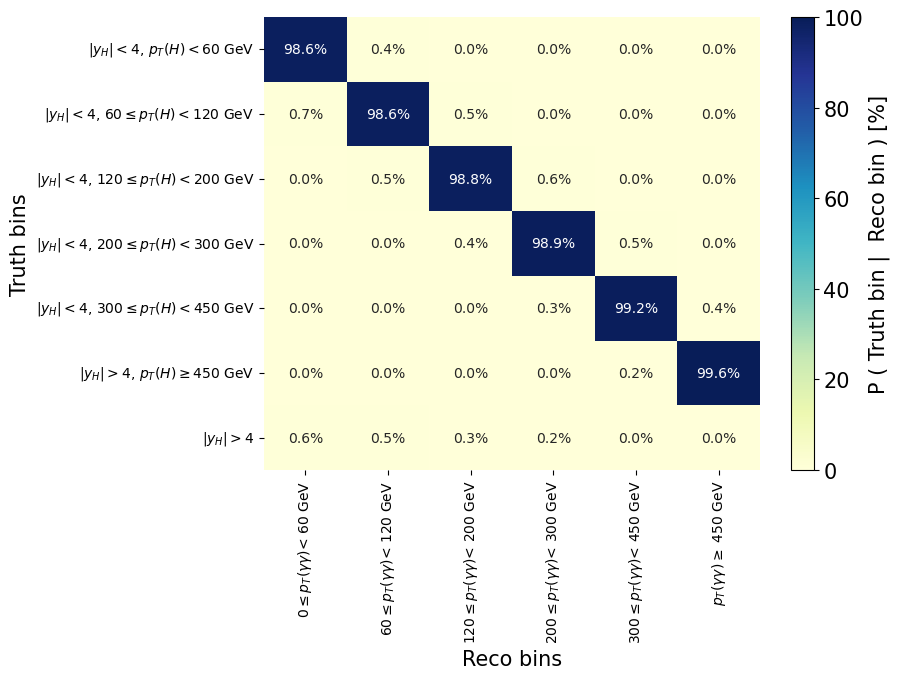

In [18]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

ax = sns.heatmap(m2, cbar = False, cmap = 'YlGnBu', vmin=0, vmax=100, annot = True, fmt = ".1f")

for t in ax.texts: 
    t.set_size(10)
    t.set_text(t.get_text() + "%")

ax.set_xlabel(r'Reco bins')
ax.set_ylabel(r'Truth bins')
ax.tick_params(axis='both', which='major', labelsize=10)
ax.tick_params(axis='both', which='minor', labelsize=10)
plt.xticks(rotation = 90)
ax.set_xticklabels(list(selection['reco'].values()))
ax.set_yticklabels(list(selection['truth'].values()))

cbar = ax.figure.colorbar(ax.collections[0])
cbar.set_label(r"P ( Truth bin |  Reco bin ) [%]")
outdir = "/eos/user/e/elmazzeo/ttH@FCC-hh/presentations/"
plotname = "probability_truth_bin_reco_bin_ttHyy"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()

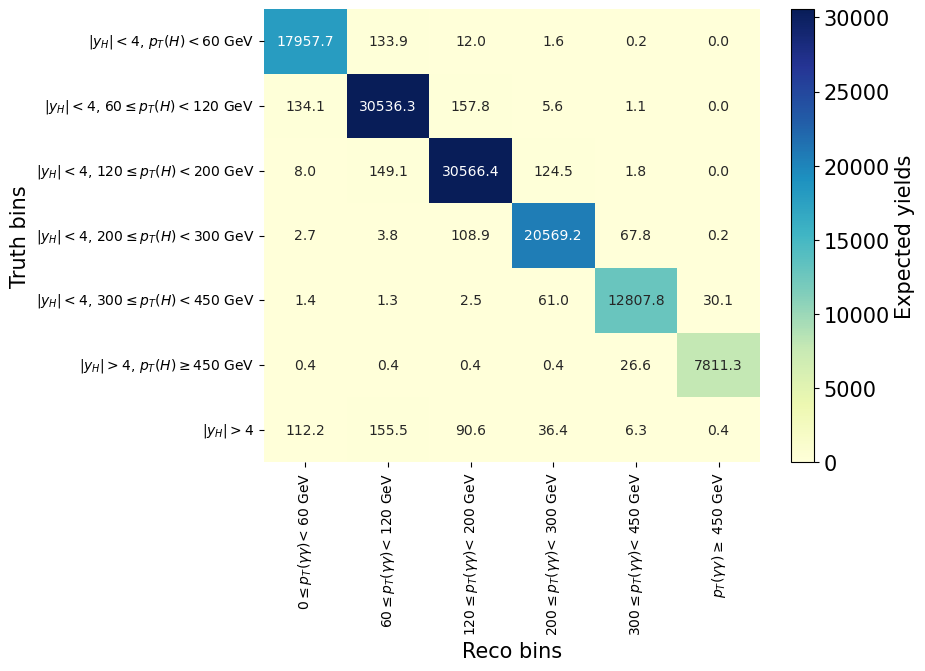

In [34]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

ax = sns.heatmap(df1, cbar = False, cmap = 'YlGnBu', vmin=0, vmax=np.max(df1), annot = True, fmt = ".1f")

for t in ax.texts: 
    t.set_size(10)
    t.set_text(t.get_text())

ax.set_xlabel(r'Reco bins')
ax.set_ylabel(r'Truth bins')
ax.tick_params(axis='both', which='major', labelsize=10)
ax.tick_params(axis='both', which='minor', labelsize=10)
plt.xticks(rotation = 90)
ax.set_xticklabels(list(selection['reco'].values()))
ax.set_yticklabels(list(selection['truth'].values()))

cbar = ax.figure.colorbar(ax.collections[0])
cbar.set_label(r"Expected yields")

plotname = "probability_reco_bin_truth_bin_ttHyy"
plt.savefig(os.path.join(outdir, plotname+".pdf"), bbox_inches='tight')
plt.savefig(os.path.join(outdir, plotname+".png"), bbox_inches='tight')
plt.show()

In [35]:
df1

,pT_yy_bin1,pT_yy_bin2,pT_yy_bin3,pT_yy_bin4,pT_yy_bin5,pT_yy_bin6
Truth bin,,,,,,
TTH_CEN_PTH_0_60,17957.667485,133.871799,11.957506,1.629040,0.180461,0.000000
TTH_CEN_PTH_60_120,134.066692,30536.307617,157.793716,5.615329,1.087326,0.000000
TTH_CEN_PTH_120_200,7.975044,149.105658,30566.444928,124.454527,1.809132,0.000000
TTH_CEN_PTH_200_300,2.716925,3.803451,108.901219,20569.165690,67.769799,0.180169
TTH_CEN_PTH_300_450,1.448237,1.268820,2.535016,61.043809,12807.846020,30.072568
TTH_CEN_PTH_450_inf,0.361478,0.362079,0.361869,0.363165,26.632254,7811.260095
TTH_FWD,112.163837,155.456831,90.591126,36.430216,6.339402,0.362859
